# Лабораторная работа I. Подготовка данных

In [1]:
!pip install -q warcio beautifulsoup4 langdetect ftfy transformers tokenizers datasets tqdm

In [2]:
import sys, os
sys.path.insert(0, "..")
os.chdir("..")

import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from src.utils import get_device, set_seeds
from configs.config import *

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = get_device()
set_seeds(42)
print(f"Device: {DEVICE}")

# --- sampling for headless run ---
SAMPLE_SIZE = 300
WARC_RECORD_LIMIT = 3000
print(f"SAMPLE_SIZE={SAMPLE_SIZE}, WARC_RECORD_LIMIT={WARC_RECORD_LIMIT}")

Device: mps
SAMPLE_SIZE=300, WARC_RECORD_LIMIT=3000


## 3.1 Скачать датасет (1 балл)

Common Crawl — это архив веб-страниц, собранных автоматическим обходом интернета. Данные Common Crawl хранятся не как текст, а как архив результатов обхода, поэтому содержат множество метаданных.

В этом задании вам необходимо:
- Скачать часть датасета Common Crawl — WARC-файл.
- Конвертировать его в текстовый формат.

### 3.1.1 Скачивание WARC-файла

In [3]:
from src.data.download import download_warc

download_warc(WARC_CRAWL_ID, WARC_PATH)

WARC уже скачан: data/raw/cc-segment.warc.gz (1.13 GB)


### 3.1.2 Конвертация в текстовый формат

In [4]:
from src.data.parse import parse_warc

raw_documents = parse_warc(WARC_PATH, limit=WARC_RECORD_LIMIT)
print(f"Извлечено документов: {len(raw_documents)}")
print(f"\n--- Пример документа ---\n{raw_documents[0][:500]}")

Parsing WARC: 0it [00:00, ?it/s]

/Users/ekaterinabulanova/Workspace/itmo/mnna/lab-1/src/data/parse.py:20: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  soup = BeautifulSoup(html, "html.parser")


Извлечено документов: 3000

--- Пример документа ---
�V�n�Q�����T��ѫǭ���
�p�G�z���s�����L�w�� Flash Player�A�Ч�� Google Chrome�BFirefox �� Microsoft Edge ���s�����A�i�J�s�����]�[�C
�p�G�z�@�w�n�ϥ� Flash Player�A�Ь�
Flash Player�L�k�ϥθѨM��k�о�
�C
�U�� Chrome �s����
�U�� Firefox �s����
�U�� Edge �s����
�^����
�x
�|������
�x
�e§���D���H
�x
�|�����I
�x
�ϥλ���
�x
�I�ڤ覡
24�p�ɫȪA�M�u :
02-27654066
�K�O���T��
�]�[���H�� :  �H
�˷R���ϥΪ�
�z�n�G
�z�{�b�Y�N�i�J [
�V�n�Q�����T��ѫ�
]
�Щ�U����n�J�z���κٶi�J��ѫǲ�ѡC�b�o�̧A�i�H���P�ۦb������ͻP�u�W�D�����Բ��,�i�J��ѫǫ�


## 3.2 Очистить данные (3 балла)

В этом задании вам необходимо:
- Удалить HTML-разметку и заголовки (header'ы).
- Удалить неизвестные языки и символы. Неизвестные языки — это те, на которых мы точно не будем обучать модель.
- Дополнительно можете добавить фильтрацию объектов по ключевым словам, чтобы отсеивать токсичные данные (необязательный пункт).
- Нормализовать пробелы и Unicode-символы.
- Удалить пустые строки.
- Слишком длинные объекты разбить на объекты поменьше. Рекомендуется обучать модель на последовательностях длиной 512-1024 токенов (это примерно 350-700 слов в каждом объекте для английского языка).

### 3.2.1 Удаление HTML-разметки и заголовков

In [5]:
from src.data.clean import clean_documents

documents = clean_documents(raw_documents)
print(f"Документов после очистки HTML: {len(documents)}")

Cleaning HTML:   0%|          | 0/3000 [00:00<?, ?it/s]

Документов после очистки HTML: 3000


### 3.2.2 Удаление неизвестных языков и символов

In [6]:
from src.data.clean import filter_by_language

documents, lang_counts = filter_by_language(documents)
print(f"\nСтатистика по языкам (top-10):")
for lang, count in lang_counts.most_common(10):
    print(f"  {lang}: {count}")
print(f"\nОсталось (en): {len(documents)}")

Language filtering:   0%|          | 0/3000 [00:00<?, ?it/s]


Статистика по языкам (top-10):
  en: 1037
  zh-cn: 266
  ru: 213
  ko: 202
  ja: 198
  bn: 158
  fr: 137
  es: 117
  de: 97
  pl: 78

Осталось (en): 1037


### 3.2.3 Нормализация пробелов и Unicode-символов

In [7]:
from src.data.clean import normalize_documents

documents = normalize_documents(documents)
print(f"Документов после нормализации: {len(documents)}")
print(f"\n--- Пример ---\n{documents[0][:300]}")

Normalizing:   0%|          | 0/1037 [00:00<?, ?it/s]

Документов после нормализации: 1037

--- Пример ---
Please click if you not a BOT
3.236.223.106 CCBot/2.0 (https://commoncrawl.org/faq/)


### 3.2.4 Удаление пустых строк

In [8]:
from src.data.clean import remove_short_documents

before = len(documents)
documents = remove_short_documents(documents)
print(f"Было: {before} → Осталось (≥20 слов): {len(documents)}")

Было: 1037 → Осталось (≥20 слов): 963


### 3.2.5 Разбиение длинных объектов

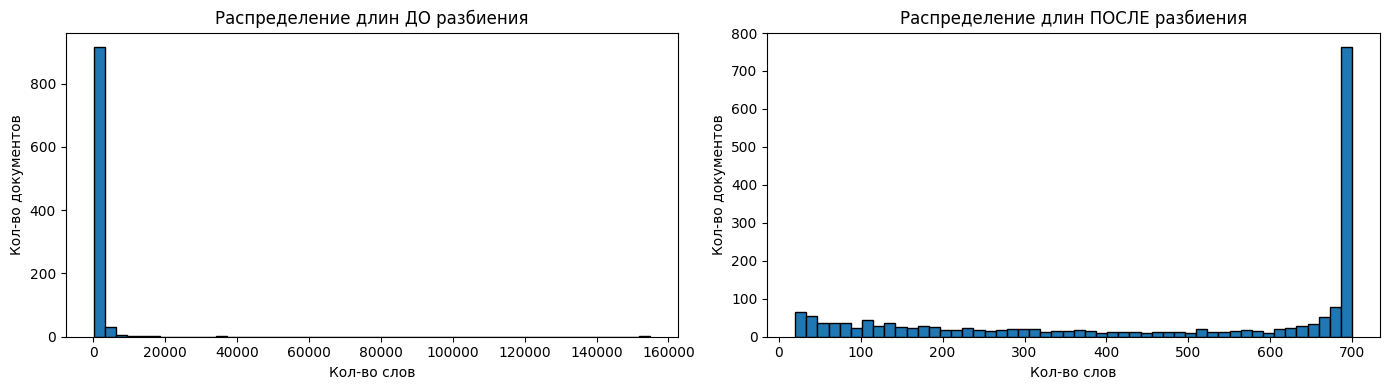

Документов после разбиения: 1911
После сэмплирования: 300


In [9]:
from src.data.clean import split_documents

lengths_before = [len(doc.split()) for doc in documents]
documents = split_documents(documents)
lengths_after = [len(doc.split()) for doc in documents]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(lengths_before, bins=50, edgecolor="black")
axes[0].set_title("Распределение длин ДО разбиения")
axes[0].set_xlabel("Кол-во слов")
axes[0].set_ylabel("Кол-во документов")
axes[1].hist(lengths_after, bins=50, edgecolor="black")
axes[1].set_title("Распределение длин ПОСЛЕ разбиения")
axes[1].set_xlabel("Кол-во слов")
axes[1].set_ylabel("Кол-во документов")
plt.tight_layout()
plt.show()
print(f"Документов после разбиения: {len(documents)}")

documents = documents[:SAMPLE_SIZE]
print(f"После сэмплирования: {len(documents)}")

## 3.3 Улучшаем качество данных (6 баллов)

Мы выполнили первичную очистку датасета. Однако данные все еще довольно грязные: в тексте могут встретиться дублирующиеся абзацы, куски с повторяющимися многократно фразами, или наоборот — бессвязный бред.

В этом задании вам необходимо:
- Для каждого объекта датасета вычислить энтропию H(D) с помощью модели GPT-2 и информационную плотность.
- Оценить информационную плотность всего датасета (подсказка: используйте взвешенное среднее) и вывести её.
- Удалить объекты-дубликаты (если есть) и объекты с крайне низкой и крайне высокой энтропией языка.

### 3.3.1 Удаление дубликатов

In [10]:
from src.data.dedup import deduplicate

before_dedup = len(documents)
documents, rho_dup = deduplicate(documents)
print(f"До дедупликации: {before_dedup}")
print(f"После дедупликации: {len(documents)}")
print(f"Удалено дубликатов: {before_dedup - len(documents)}")
print(f"Дублирующая плотность ρ_dub = {rho_dup:.4f}")

До дедупликации: 300
После дедупликации: 277
Удалено дубликатов: 23
Дублирующая плотность ρ_dub = 1.0830


### 3.3.2 Вычисление энтропии H(D) с помощью GPT-2

In [11]:
from src.models.entropy import load_gpt2, compute_entropy_batch

gpt2_model, gpt2_tokenizer = load_gpt2(DEVICE)
print(f"GPT-2 загружена на {DEVICE}")

entropies, token_counts = compute_entropy_batch(documents, gpt2_model, gpt2_tokenizer, DEVICE)

valid_count = sum(1 for e in entropies if e is not None)
print(f"Вычислена энтропия для {valid_count} из {len(documents)} документов")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT-2 загружена на mps


Entropy batches:   0%|          | 0/35 [00:00<?, ?it/s]

Вычислена энтропия для 277 из 277 документов


### 3.3.3 Информационная плотность датасета

In [12]:
from src.models.entropy import compute_info_density

rho_info = compute_info_density(entropies, token_counts)
valid_entropies = np.array([e for e in entropies if e is not None])
print(f"Информационная плотность датасета ρ_info = {rho_info:.4f} nats/token")
print(f"Средняя энтропия (невзвешенная): {valid_entropies.mean():.4f}")
print(f"Медианная энтропия: {np.median(valid_entropies):.4f}")

Информационная плотность датасета ρ_info = 2.9917 nats/token
Средняя энтропия (невзвешенная): 3.2331
Медианная энтропия: 3.3253


### 3.3.4 Фильтрация по энтропии

Пороги энтропии: [1.4259, 4.5400]


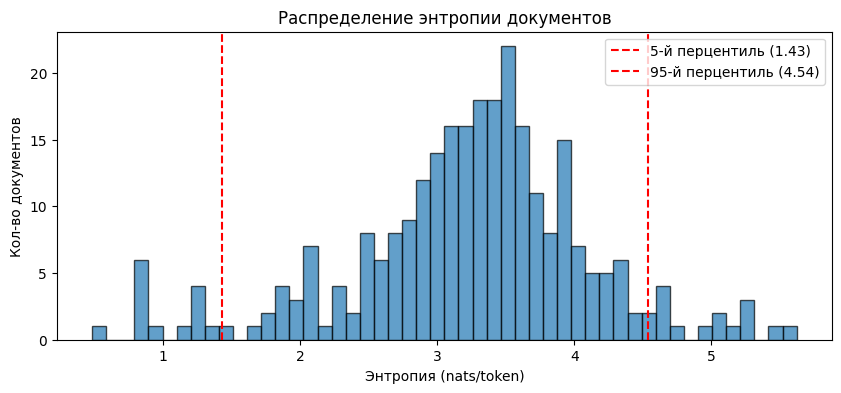


Было: 277 → Осталось: 249


In [13]:
from src.models.entropy import filter_by_entropy

before_filter = len(documents)
documents, (low_threshold, high_threshold) = filter_by_entropy(documents, entropies, token_counts)
print(f"Пороги энтропии: [{low_threshold:.4f}, {high_threshold:.4f}]")

plt.figure(figsize=(10, 4))
plt.hist(valid_entropies, bins=50, edgecolor="black", alpha=0.7)
plt.axvline(low_threshold, color="red", linestyle="--", label=f"5-й перцентиль ({low_threshold:.2f})")
plt.axvline(high_threshold, color="red", linestyle="--", label=f"95-й перцентиль ({high_threshold:.2f})")
plt.xlabel("Энтропия (nats/token)")
plt.ylabel("Кол-во документов")
plt.title("Распределение энтропии документов")
plt.legend()
plt.show()

print(f"\nБыло: {before_filter} → Осталось: {len(documents)}")

## 3.4 Токенизация текста (6 баллов)

Текст очищен, теперь необходимо конвертировать его в формат, понятный для языковой модели. Реализуйте токенизацию:
- Реализуйте токенизацию по символам. Выведите размер словаря и размер последовательности случайного объекта из датасета.
- Реализуйте токенизацию по словам. Выведите размер словаря и размер последовательности случайного объекта из датасета.
- Реализуйте BPE-токенизацию.

### 3.4.1 Токенизация по символам

In [14]:
from src.tokenization.char_tokenizer import CharTokenizer

char_tok = CharTokenizer()
char_tok.build_vocab(documents)

sample_idx = random.randint(0, len(documents) - 1)
sample_encoded = char_tok.encode(documents[sample_idx])

print(f"Размер словаря (символы): {char_tok.vocab_size}")
print(f"Размер последовательности случайного объекта: {len(sample_encoded)}")
print(f"Пример текста: {documents[sample_idx][:100]}...")
print(f"Пример токенов: {sample_encoded[:50]}...")

Размер словаря (символы): 1838
Размер последовательности случайного объекта: 3944
Пример текста: Digging into a little deeper, apparently the federal government has a fleet of 1700 private jets.
Ly...
Пример токенов: [37, 73, 71, 71, 73, 78, 71, 1, 73, 78, 84, 79, 1, 65, 1, 76, 73, 84, 84, 76, 69, 1, 68, 69, 69, 80, 69, 82, 13, 1, 65, 80, 80, 65, 82, 69, 78, 84, 76, 89, 1, 84, 72, 69, 1, 70, 69, 68, 69, 82]...


### 3.4.2 Токенизация по словам

In [15]:
from src.tokenization.word_tokenizer import WordTokenizer

word_tok = WordTokenizer()
word_tok.build_vocab(documents, vocab_size=WORD_VOCAB_SIZE)

sample_idx = random.randint(0, len(documents) - 1)
sample_encoded = word_tok.encode(documents[sample_idx])

print(f"Размер словаря (слова): {word_tok.vocab_size}")
print(f"Всего уникальных слов в корпусе: {word_tok.total_unique}")
print(f"Размер последовательности случайного объекта: {len(sample_encoded)}")
print(f"Пример текста: {documents[sample_idx][:100]}...")
print(f"Пример токенов: {sample_encoded[:30]}...")

Building word vocab:   0%|          | 0/249 [00:00<?, ?it/s]

Размер словаря (слова): 19710
Всего уникальных слов в корпусе: 19708
Размер последовательности случайного объекта: 212
Пример текста: 5Bricks
뒤로
뒤로
더보기
게시물 알림
내 글 반응
내가 작성한 게시물이나 댓글에 다른 사람이 댓글이나 답글을 작성하면 알려줍니다.
공지사항
사이트에서 보내는 중요한 공지를 ...
Пример токенов: [5745, 5746, 5746, 8810, 8811, 8812, 8813, 8814, 8815, 8816, 8817, 8818, 8819, 8820, 8821, 8822, 8823, 8824, 5747, 2, 8825, 8826, 8827, 8828, 8829, 8830, 5747, 2, 8831, 8832]...


### 3.4.3 BPE-токенизация

In [16]:
from src.tokenization.bpe_tokenizer import train_bpe

bpe_tokenizer = train_bpe(documents, BPE_VOCAB_SIZE, BPE_PATH)

sample_idx = random.randint(0, len(documents) - 1)
encoded = bpe_tokenizer.encode(documents[sample_idx])

print(f"Размер словаря (BPE): {bpe_tokenizer.get_vocab_size()}")
print(f"Размер последовательности случайного объекта: {len(encoded.ids)}")
print(f"Пример текста: {documents[sample_idx][:100]}...")
print(f"Пример токенов: {encoded.ids[:30]}...")
print(f"Пример подслов: {encoded.tokens[:30]}...")
print(f"Декодирование: {bpe_tokenizer.decode(encoded.ids)[:100]}...")


Размер словаря (BPE): 32000
Размер последовательности случайного объекта: 222
Пример текста: Trade News-Wendar Enterprise Co., Ltd.-Telescopic Ladders,Extention Ladders,Aluminium Stepladders,Sc...
Пример токенов: [10967, 1362, 16, 24728, 5661, 31061, 1713, 3232, 6695, 11778, 15874, 2472, 30035, 14920, 15, 4802, 3305, 14920, 15, 1125, 6043, 1788, 20624, 15, 1303, 2159, 655, 8741, 189, 15]...
Пример подслов: ['Trade', 'ĠNews', '-', 'Wendar', 'ĠEnter', 'prise', 'ĠCo', '.,', 'ĠLtd', '.-', 'Tel', 'esc', 'opic', 'ĠLadders', ',', 'Ext', 'ention', 'ĠLadders', ',', 'Al', 'umin', 'ium', 'ĠStepladders', ',', 'Sc', 'aff', 'old', 'ĠLadd', 'er', ',']...
Декодирование: Trade News-Wendar Enterprise Co., Ltd.-Telescopic Ladders,Extention Ladders,Aluminium Stepladders,Sc...


## 3.5 Датасет для обучения модели (4 балла)

Скачайте датасет wikitext (Hugging Face). Выполните все предыдущие задания, но теперь с wikitext. Код у вас уже написан, просто вызовите его снова, но для нового датасета. Исключение — BPE токенизатор, используйте тот, что обучен на Common Crawl.

После получения всех результатов реализуйте механизм packed batching.

При формировании батчей данных необходимо чтобы все объекты были одной длины. Простой способ — добавить `<PAD>`-токены для каждой последовательности, чтобы увеличить их до размера самой длинной последовательности.

Чтобы эти `<PAD>`-токены не влияли на вычисление механизма внимания, для каждого объекта создадим маску. Если на этом индексе находится `<PAD>`-токен, то значение маски равно 0, иначе — 1.

Packed batching — это способ объединить несколько коротких объектов в один. Чтобы не смешивать позиционное кодирование и внимание между двумя объектами, обновим маску. Для `<PAD>`-токенов значение маски остается равным 0, для первого объекта — 1, для второго — 2 (и так далее).

### 3.5.1 Загрузка WikiText

In [17]:
from src.data.wiki import load_wikitext_articles

wiki_texts = load_wikitext_articles()[:SAMPLE_SIZE]
print(f"WikiText статей (train): {len(wiki_texts)}")
print(f"Пример: {wiki_texts[0][:300]}")

WikiText статей (train): 300
Пример: Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ playing video game developed by Sega and Media.Vision for the PlayStation Portable . Released in Janua


### 3.5.2 Очистка WikiText (задания 3.2-3.3)

In [18]:
from src.data.clean import clean_wikitext, normalize_text, remove_empty_lines, split_long_document
from src.data.dedup import deduplicate
from src.models.entropy import compute_entropy_batch, compute_info_density, filter_by_entropy, unload_gpt2

print("=== Очистка артефактов WikiText ===")
wiki_docs = [clean_wikitext(doc) for doc in wiki_texts]

print("=== Нормализация ===")
wiki_docs = [normalize_text(doc) for doc in tqdm(wiki_docs, desc="Normalizing WikiText")]

print("=== Удаление пустых строк и коротких документов ===")
wiki_docs = [remove_empty_lines(doc) for doc in wiki_docs]
wiki_docs = [doc for doc in wiki_docs if len(doc.split()) >= MIN_WORDS]
print(f"После удаления пустых/коротких: {len(wiki_docs)}")

print("=== Разбиение длинных объектов ===")
split_wiki = []
for doc in wiki_docs:
    split_wiki.extend(split_long_document(doc))
wiki_docs = split_wiki[:SAMPLE_SIZE]
print(f"После разбиения: {len(wiki_docs)}")

before = len(wiki_docs)
wiki_docs, wiki_rho_dup = deduplicate(wiki_docs)
print(f"\nДедупликация: {before} → {len(wiki_docs)}, ρ_dub = {wiki_rho_dup:.4f}")

print("\n=== Вычисление энтропии WikiText ===")
wiki_entropies, wiki_token_counts = compute_entropy_batch(wiki_docs, gpt2_model, gpt2_tokenizer, DEVICE)

wiki_rho_info = compute_info_density(wiki_entropies, wiki_token_counts)
print(f"Информационная плотность WikiText ρ_info = {wiki_rho_info:.4f}")

before = len(wiki_docs)
wiki_docs, (wiki_low, wiki_high) = filter_by_entropy(wiki_docs, wiki_entropies, wiki_token_counts)
print(f"Фильтрация по энтропии [{wiki_low:.2f}, {wiki_high:.2f}]: {before} → {len(wiki_docs)}")

unload_gpt2(gpt2_model, DEVICE)
print("GPT-2 выгружена из памяти")

=== Очистка артефактов WikiText ===
=== Нормализация ===


Normalizing WikiText:   0%|          | 0/300 [00:00<?, ?it/s]

=== Удаление пустых строк и коротких документов ===
После удаления пустых/коротких: 298
=== Разбиение длинных объектов ===
После разбиения: 300

Дедупликация: 300 → 300, ρ_dub = 1.0000

=== Вычисление энтропии WikiText ===


Entropy batches:   0%|          | 0/38 [00:00<?, ?it/s]

Информационная плотность WikiText ρ_info = 3.3549
Фильтрация по энтропии [2.88, 3.81]: 300 → 270
GPT-2 выгружена из памяти


### 3.5.3 Токенизация WikiText (BPE от Common Crawl)

In [19]:
from src.tokenization.bpe_tokenizer import load_bpe

bpe_tokenizer_loaded = load_bpe(BPE_PATH)
wiki_bpe_encoded = [bpe_tokenizer_loaded.encode(doc).ids for doc in tqdm(wiki_docs, desc="BPE WikiText")]

lengths = [len(seq) for seq in wiki_bpe_encoded]
print(f"Токенизировано документов: {len(wiki_bpe_encoded)}")
print(f"Средняя длина: {np.mean(lengths):.1f} токенов")
print(f"Медианная длина: {np.median(lengths):.1f} токенов")
print(f"Макс длина: {max(lengths)} токенов")

sample_idx = random.randint(0, len(wiki_docs) - 1)
print(f"\nПример текста: {wiki_docs[sample_idx][:200]}...")
print(f"BPE токены: {wiki_bpe_encoded[sample_idx][:30]}...")

BPE WikiText:   0%|          | 0/270 [00:00<?, ?it/s]

Токенизировано документов: 270
Средняя длина: 836.0 токенов
Медианная длина: 854.5 токенов
Макс длина: 1227 токенов

Пример текста: The 1806 Great Coastal hurricane was a severe and damaging storm along the East Coast of the United States which produced upwards of 36 in ( 91 cm ) of rainfall in parts of Massachusetts . First obser...
BPE токены: [466, 2121, 2028, 7585, 13965, 204, 28030, 1093, 526, 193, 766, 322, 71, 233, 27869, 6027, 341, 529, 2336, 208, 4131, 13965, 230, 208, 2813, 3507, 1038, 14838, 709, 4497]...


### 3.5.4 Packed Batching

In [20]:
from src.batching import packed_batching, PackedDataset

PAD_ID = bpe_tokenizer_loaded.token_to_id("<PAD>")
packed_inputs, packed_masks = packed_batching(wiki_bpe_encoded, TARGET_LEN, PAD_ID)

print(f"Packed sequences: {len(packed_inputs)}")
print(f"Target length: {TARGET_LEN}")

pad_tokens_total = sum(m.count(0) for m in packed_masks)
total_tokens = len(packed_inputs) * TARGET_LEN
print(f"PAD-токенов: {pad_tokens_total} / {total_tokens} ({100 * pad_tokens_total / total_tokens:.1f}%)")

print(f"\n--- Пример packed batch [0] ---")
print(f"Tokens (первые 50): {packed_inputs[0][:50]}")
print(f"Mask   (первые 50): {packed_masks[0][:50]}")
unique_docs = set(packed_masks[0]) - {0}
print(f"Документов в этом packed batch: {len(unique_docs)}")

dataset = PackedDataset(packed_inputs, packed_masks)
print(f"\nDataset size: {len(dataset)}")
sample = dataset[0]
ids_shape = sample['input_ids'].shape
mask_shape = sample['attention_mask'].shape
print(f"Sample input_ids shape: {ids_shape}")
print(f"Sample attention_mask shape: {mask_shape}")

assert sample["input_ids"].shape[0] == TARGET_LEN
assert sample["attention_mask"].shape[0] == TARGET_LEN
assert (sample["attention_mask"] >= 0).all()
print("\nВсе проверки пройдены!")

Packed sequences: 270
Target length: 512
PAD-токенов: 1402 / 138240 (1.0%)

--- Пример packed batch [0] ---
Tokens (первые 50): [15815, 76, 26079, 1023, 426, 1187, 91, 30098, 521, 1432, 887, 4993, 30155, 585, 2366, 3636, 245, 10478, 1432, 154, 1091, 102, 4545, 498, 406, 115, 296, 97, 4431, 7563, 406, 101, 20619, 22, 1708, 17282, 1989, 426, 1187, 91, 30098, 230, 208, 17213, 3597, 521, 16459, 1708, 13557, 6040]
Mask   (первые 50): [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Документов в этом packed batch: 1

Dataset size: 270
Sample input_ids shape: torch.Size([512])
Sample attention_mask shape: torch.Size([512])

Все проверки пройдены!
